for this one the sequence was:
Only active data.
Full session: 2min pre eyes closed, 6min during eyes closed, 6min post eyes closed. 30min stimulation. Participant engaged in cognitive tasks during stimulation
We have 6 markers:
Marker 1: end of eyes closed on pre
Marker 2: start of eyes closed on during && start of stimulation
Marker 3: end of eyes closed during
Marker 4: end of stimulation
Marker 5: start of eyes closed post stimulation
Marker 6: end of eyes closed post stimulation


In [1]:
from pathlib import Path

Data_path = Path.home()/ "OneDrive - The University of Nottingham" / "Data" / "ZenbudV3_Test" / "RawData"
Results = Path.home() / "OneDrive - The University of Nottingham" / "Data" / "ZenbudV3_Test"

# Frequency & FFT Parameters
FMIN = 1.0
FMAX = 48.0
N_FFT = 1024 * 4         # 4-second Welch window
N_OVERLAP = 1024 * 2     # 50% overlap

# Time-Resolved Windowing
WINDOW_LENGTH_SEC = 30.0  # 20-second consecutive windows

# Channels of interest
EEG_CHANNELS = ["O1", "O2", "Oz", "P3", "P4", "Pz"] #["O1", "O2", "Oz", "P3", "P4", "Pz"]


In [2]:
import matplotlib.pyplot as plt
import numpy as np


def filter_segment(raw, bad_channels=None, low_freq=1.0, high_freq=48.0, notch_freq=50.0, output_file=None):
    """
    Applies channel dropping, band-pass, and notch filters to an MNE Raw object.
    Optionally saves the filtered raw object to disk if output_file is specified.
    """
    raw_filtered = raw.copy()

    # Drop specified bad channels
    if bad_channels:
        channels_to_remove = [ch for ch in bad_channels if ch in raw_filtered.ch_names]
        if channels_to_remove:
            raw_filtered.drop_channels(channels_to_remove)

    # Band-pass filter (e.g., 1-45 Hz)
    raw_filtered.filter(
        l_freq=low_freq,
        h_freq=high_freq,
        picks="eeg",
        method="fir",
        fir_window="hamming",
        h_trans_bandwidth=5.0,
        phase="zero",
        verbose=False
    )

    # Notch filter (e.g., 50 Hz line noise)
    if notch_freq is not None:
        raw_filtered.notch_filter(
            freqs=notch_freq,
            picks="eeg",
            method="fir",
            phase="zero",
            verbose=False
        )

    # Apply Common Average Reference (CAR)
    # projection=False applies the reference directly to the data array immediately
    raw_filtered.set_eeg_reference(
        ref_channels="average", projection=False, verbose=False
    )

    # Optional: Save to disk
    if output_file is not None:
        raw_filtered.save(output_file, overwrite=True, verbose=False)

    return raw_filtered

In [3]:
import mne

PARTICIPANT_ID = "Test1"
EEG_VISIT = "Visit1"
vhdr_path_stimulation = Data_path / "ZenBudV3_Test1_2026-09-21_11-43-56.vhdr"
vhdr_path_sham = Data_path / "ZenBudV3_Test1_2026-09-21_12-26-54.vhdr"

def extract_blocks_from_file(vhdr_path, is_stimulation=False):
    """
    Loads a BrainVision file, selects the target segment,
    and crops pre, during, and post blocks using 3 Stimulus/s1000 markers.
    """
    print(f"\nProcessing: {vhdr_path.name}")
    raw = mne.io.read_raw_brainvision(vhdr_path, preload=True, verbose=False)

    NON_EEG_CHANNELS = ["ECG", "EAR", "RESPIRATION", "TEMPERATURE", "GSR"]
    remove_channels = [ch for ch in raw.ch_names if ch.upper() in NON_EEG_CHANNELS]
    raw.drop_channels(remove_channels)

    montage = mne.channels.make_standard_montage("standard_1020")
    raw.set_montage(montage, match_case=False, on_missing="ignore")

    # --- Isolate target segment ---
    if is_stimulation:
        new_seg_onsets = [
            annot['onset'] for annot in raw.annotations
            if 'new segment' in annot['description'].lower()
        ]

        if new_seg_onsets:
            last_segment_start = new_seg_onsets[-1]
            print(f"  Filtering Stimulation file: keeps last segment starting at {last_segment_start:.2f}s")
            raw_target = raw.crop(tmin=last_segment_start, tmax=None)
        else:
            raw_target = raw
    else:
        raw_target = raw

    # --- Extract Events ---
    events, event_id = mne.events_from_annotations(raw_target, verbose=False)

    if 'Stimulus/s1000' not in event_id:
        raise KeyError(f"'Stimulus/s1000' marker not found in {vhdr_path.name}")

    stim_code = event_id['Stimulus/s1000']
    stim_samples = events[events[:, 2] == stim_code, 0]

    if len(stim_samples) < 3:
        raise ValueError(f"Expected 3"
                         f" 'Stimulus/s1000' markers, but found {len(stim_samples)} in {vhdr_path.name}")

    # --- Convert sample indices to seconds relative to raw_target (t=0s) ---
    sfreq = raw_target.info['sfreq']
    relative_samples = stim_samples - raw_target.first_samp
    stim_times = relative_samples / sfreq

    t_start_stim = stim_times[0]  # Marker 1: Pre/During transition
    t_end_stim   = stim_times[1]  # Marker 2: Intermediate marker
    t_post_end   = stim_times[2]  # Marker 3: During/Post transition

    print(f"  Marker timings relative to segment start: "
          f"M1={t_start_stim:.2f}s, M2={t_end_stim:.2f}s, M3={t_post_end:.2f}s")

    #filtering
    filtered_target = filter_segment(raw_target.copy())

    # --- Slice into Pre, During, and Post continuous blocks ---
    raw_pre = filtered_target.copy().crop(tmin=0.0+10, tmax=t_start_stim)
    raw_during = filtered_target.copy().crop(tmin=t_start_stim, tmax=t_end_stim)
    raw_post = filtered_target.copy().crop(tmin=t_end_stim, tmax=raw_target.times[-1])

    # filtered_pre = filter_segment(raw_pre)
    # filtered_post = filter_segment(raw_post)
    # filtered_during = filter_segment(raw_during)

    print(f"  Successfully extracted blocks:")
    print(f"    - Pre:    {raw_pre.times[-1]:.2f}s long")
    print(f"    - During: {raw_during.times[-1]:.2f}s long ({t_end_stim - t_start_stim:.2f}s)")
    print(f"    - Post:   {raw_post.times[-1]:.2f}s long")

    return {
        'pre': raw_pre,
        'during': raw_during,
        'post': raw_post,
    }

#Run extraction for both files
stim_blocks_1 = extract_blocks_from_file(vhdr_path_stimulation, is_stimulation=True)
sham_blocks_1 = extract_blocks_from_file(vhdr_path_sham, is_stimulation=False)


Processing: ZenBudV3_Test1_2026-09-21_11-43-56.vhdr


C:\Users\AFalcon\AppData\Local\Temp\ipykernel_35568\4279899537.py:14: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_brainvision(vhdr_path, preload=True, verbose=False)
C:\Users\AFalcon\AppData\Local\Temp\ipykernel_35568\4279899537.py:20: FutureWarning: Montage name 'standard_1020' is deprecated and will be removed in MNE 1.14. Use 'colin27_1020' instead.
  montage = mne.channels.make_standard_montage("standard_1020")


  Filtering Stimulation file: keeps last segment starting at 317.06s
  Marker timings relative to segment start: M1=87.98s, M2=421.91s, M3=608.23s
  Successfully extracted blocks:
    - Pre:    77.98s long
    - During: 333.93s long (333.93s)
    - Post:   201.15s long

Processing: ZenBudV3_Test1_2026-09-21_12-26-54.vhdr


C:\Users\AFalcon\AppData\Local\Temp\ipykernel_35568\4279899537.py:14: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_brainvision(vhdr_path, preload=True, verbose=False)
C:\Users\AFalcon\AppData\Local\Temp\ipykernel_35568\4279899537.py:20: FutureWarning: Montage name 'standard_1020' is deprecated and will be removed in MNE 1.14. Use 'colin27_1020' instead.
  montage = mne.channels.make_standard_montage("standard_1020")


  Marker timings relative to segment start: M1=151.91s, M2=452.66s, M3=704.15s
  Successfully extracted blocks:
    - Pre:    141.91s long
    - During: 300.75s long (300.75s)
    - Post:   526.30s long


In [4]:
PARTICIPANT_ID = "Test2"
EEG_VISIT = "Visit1"
#extract stim data from new test
vhdr_path_stimulation_2 = Data_path / "Test2"/"ZenbudV3_Test2_2026-09-22_12-27-04.vhdr"

print(f"\nProcessing: {vhdr_path_stimulation_2.name}")

raw = mne.io.read_raw_brainvision(vhdr_path_stimulation_2, preload=True, verbose=False)

NON_EEG_CHANNELS = ["ECG", "EAR", "RESPIRATION", "TEMPERATURE", "GSR"]
remove_channels = [ch for ch in raw.ch_names if ch.upper() in NON_EEG_CHANNELS]
raw.drop_channels(remove_channels)

montage = mne.channels.make_standard_montage("standard_1020")
raw.set_montage(montage, match_case=False, on_missing="ignore")

# --- Extract Events ---
events, event_id = mne.events_from_annotations(raw, verbose=False)

if 'Stimulus/s1000' not in event_id:
    raise KeyError(f"'Stimulus/s1000' marker not found in {vhdr_path_stimulation_2.name}")

stim_code = event_id['Stimulus/s1000']
stim_samples = events[events[:, 2] == stim_code, 0]

if len(stim_samples) < 6:
    raise ValueError(f"Expected 6"
                    f" 'Stimulus/s1000' markers, but found {len(stim_samples)} in {vhdr_path_stimulation_2.name}")

# --- Convert sample indices to seconds relative to raw_target (t=0s) ---
sfreq = raw.info['sfreq']
stim_times = stim_samples / sfreq

t_end_pre_EC = stim_times[1]  # Marker 1: end eyes closed pre-stimulation
t_start_stim = stim_times[1]  # Marker 2: start stimulation && start eyes closed during stimulation
t_end_during_EC = stim_times[2]  # Marker 3: end eyes closed during stimulation
t_end_stim  = stim_times[3]  # Marker 4: end stimulation
t_start_post_EC  = stim_times[4]  # Marker 5: start eyes closed post stimulation
t_end_post_EC  = stim_times[5]  # Marker 6: end eyes closed post-stimulation

#filtering
filtered_data = filter_segment(raw.copy())

# --- Slice into Pre, During, and Post continuous blocks ---
raw_pre = filtered_data.copy().crop(tmin=0.0, tmax=t_start_stim)
raw_during = filtered_data.copy().crop(tmin=t_start_stim, tmax=t_end_stim-5)
raw_post = filtered_data.copy().crop(tmin=t_end_stim+10, tmax=t_end_post_EC)

print(f"  Successfully extracted blocks:")
print(f"    - Pre:    {raw_pre.times[-1]:.2f}s long")
print(f"    - During: {raw_during.times[-1]:.2f}s long")
print(f"    - Post:   {raw_post.times[-1]:.2f}s long")

stim_blocks_2= {
        'pre': raw_pre,
        'during': raw_during,
        'post': raw_post
    }


Processing: ZenbudV3_Test2_2026-09-22_12-27-04.vhdr


C:\Users\AFalcon\AppData\Local\Temp\ipykernel_35568\3308177299.py:8: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_brainvision(vhdr_path_stimulation_2, preload=True, verbose=False)
C:\Users\AFalcon\AppData\Local\Temp\ipykernel_35568\3308177299.py:14: FutureWarning: Montage name 'standard_1020' is deprecated and will be removed in MNE 1.14. Use 'colin27_1020' instead.
  montage = mne.channels.make_standard_montage("standard_1020")


  Successfully extracted blocks:
    - Pre:    203.93s long
    - During: 1871.88s long
    - Post:   391.74s long


Static PSD DataFrame created: 3402 rows.


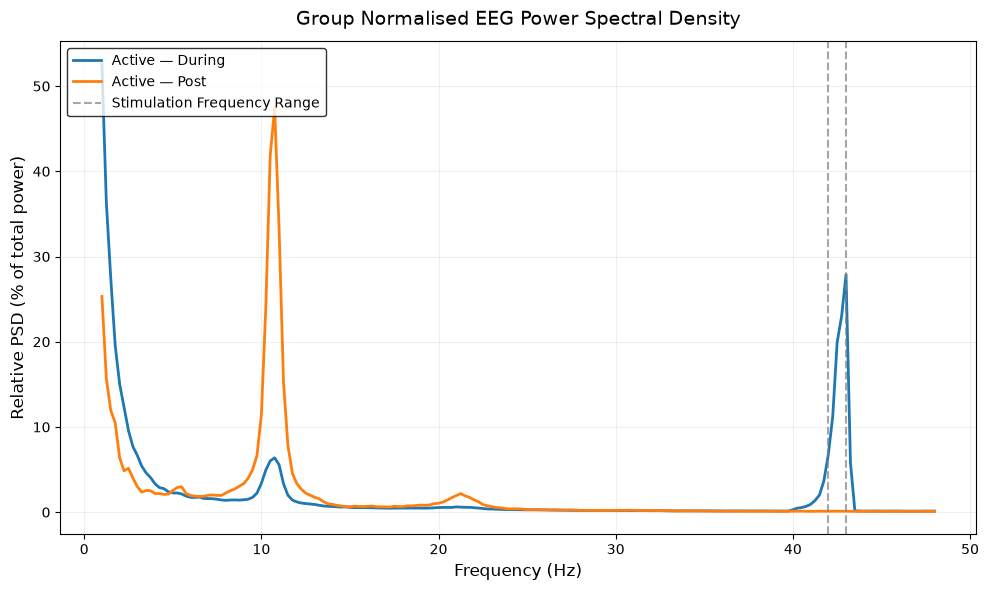

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==============================================================================
# CONFIGURATION & PARAMETERS
# ==============================================================================
ANALYSIS_PATH = Path(Results/"analysis_output")
ANALYSIS_PATH.mkdir(parents=True, exist_ok=True)

# Tuple structure: (participant_id, condition_label, block_dict)
datasets = [
    #("Test1", "Active", stim_blocks_1),
    #("Test1", "Sham", sham_blocks_1),
    ("Test2", "Active", stim_blocks_2)
]

# ==============================================================================
# STEP 1: COMPUTE STATIC PSD FOR ALL BLOCKS (Creates psd_df_41Hz)
# ==============================================================================
psd_records = []

for participant_id, condition, blocks in datasets:
    for phase, raw in blocks.items():
        avail_chs = [ch for ch in EEG_CHANNELS if ch in raw.ch_names]

        spectrum = raw.compute_psd(
            method="welch",
            fmin=FMIN,
            fmax=FMAX,
            picks=avail_chs,
            n_fft=N_FFT,
            n_overlap=N_OVERLAP,
            verbose=False
        )

        psd_data = spectrum.get_data()  # shape: (n_channels, n_freqs)
        freqs = spectrum.freqs

        for ch_idx, ch_name in enumerate(spectrum.ch_names):
            for freq_idx, freq in enumerate(freqs):
                psd_records.append({
                    "participant": PARTICIPANT_ID,
                    "eeg_visit": EEG_VISIT,
                    "condition": condition,
                    "phase": phase,
                    "channel": ch_name,
                    "frequency": freq,
                    "psd": psd_data[ch_idx, freq_idx]
                })

psd_df_41Hz = pd.DataFrame(psd_records)
print(f"Static PSD DataFrame created: {len(psd_df_41Hz)} rows.")


# ==============================================================================
# STEP 3: ANALYZE & PLOT STATIC NORMALISED GROUP PSD
# ==============================================================================
# 1. Average channels per participant/condition/phase/frequency
participant_psd = (
    psd_df_41Hz
    .groupby(["participant", "eeg_visit", "condition", "phase", "frequency"], as_index=False)
    .agg(psd=("psd", "mean"))
    .sort_values(["participant", "eeg_visit", "condition", "phase", "frequency"])
)

# 2. Calculate Total Power per participant/visit/condition/phase using trapezoidal integration
participant_cols = ["participant", "eeg_visit", "condition", "phase"]

participant_psd["total_power"] = participant_psd.sort_values("frequency").groupby(participant_cols)["psd"].transform(
    lambda psd: np.trapezoid(psd, participant_psd.loc[psd.index, "frequency"])
)

# 3. Calculate Relative PSD (% of total power)
participant_psd["relative_psd"] = participant_psd["psd"] / participant_psd["total_power"]

# 4. Group mean & error metrics across participants
group_relative_psd = (
    participant_psd

    .groupby(["condition", "phase", "frequency"], as_index=False)
    .agg(
        mean_relative_psd=("relative_psd", "mean"),
        sd_relative_psd=("relative_psd", "std"),
        n=("relative_psd", "count")
    )
)

# Avoid NaN SEM if running single participant
group_relative_psd["sd_relative_psd"] = group_relative_psd["sd_relative_psd"].fillna(0)
group_relative_psd["sem_relative_psd"] = group_relative_psd["sd_relative_psd"] / np.sqrt(group_relative_psd["n"])

# 5. Plotting group normalised results
fig, ax = plt.subplots(figsize=(10, 6), facecolor="w")

for condition, phase in [
    ("Active", "during"),
    ("Sham", "during"),
    ("Active", "post"),
    ("Sham", "post")
]:
    subset = group_relative_psd[
        (group_relative_psd["condition"] == condition) &
        (group_relative_psd["phase"] == phase)
    ].sort_values("frequency")

    if not subset.empty:
        ax.plot(
            subset["frequency"],
            subset["mean_relative_psd"] * 100,
            linewidth=2,
            label=f"{condition} — {phase.capitalize()}"
        )
ax.axvline(
    x=42,
    color="gray",
    linestyle="--",
    alpha=0.7
)
ax.axvline(
    x=43,
    color="gray",
    linestyle="--",
    alpha=0.7,
    label="Stimulation Frequency Range",
)

for spine in ax.spines.values():
    spine.set_color('black')
    spine.set_visible(True)

ax.set_facecolor('white')
ax.set_xlabel("Frequency (Hz)", fontsize=12, color="black")
ax.set_ylabel("Relative PSD (% of total power)", fontsize=12, color="black")
ax.set_title("Group Normalised EEG Power Spectral Density", fontsize=14, color="black", pad=12)
ax.tick_params(colors="black", which="both", labelsize=10)
ax.grid(alpha=0.2)

legend = ax.legend(loc="upper left", frameon=True, facecolor="white", edgecolor="black")
for text in legend.get_texts():
    text.set_color("black")

plt.tight_layout()
plt.savefig(
    ANALYSIS_PATH / "NewGroupNormalisedEEGPowerSpectralDensity_1-45Hz.png",
    dpi=300,
    facecolor=fig.get_facecolor(),
    edgecolor="none"
)
plt.show()



Time-resolved PSD DataFrame created: 91854 rows.


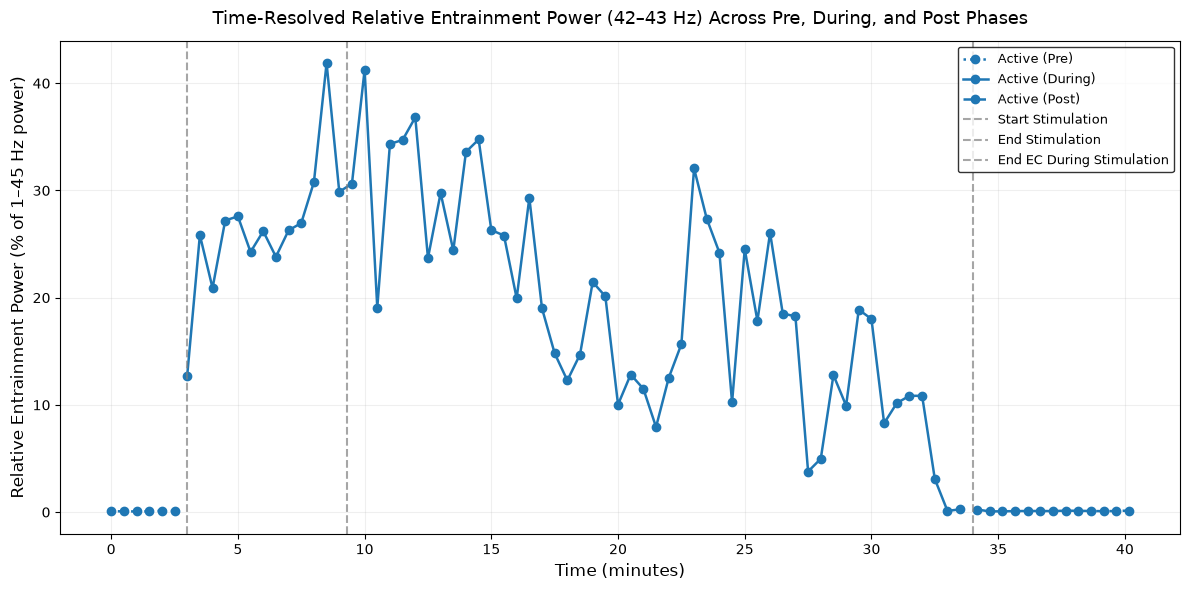

In [6]:
# ==============================================================================
# STEP 2: COMPUTE TIME-RESOLVED PSD (Creates time_psd_df)
# ==============================================================================
time_psd_results = []

for participant_id, condition, blocks in datasets:
    #if condition == "Active" and participant_id != "Test2":
     #   continue
    for phase, raw in blocks.items():
        avail_chs = [ch for ch in EEG_CHANNELS if ch in raw.ch_names]
        n_windows = int(raw.times[-1] // WINDOW_LENGTH_SEC)

        for window_idx in range(n_windows):
            start_time = window_idx * WINDOW_LENGTH_SEC
            stop_time = start_time + WINDOW_LENGTH_SEC

            window = raw.copy().crop(
                tmin=start_time,
                tmax=stop_time,
                include_tmax=False
            )

            spectrum = window.compute_psd(
                method="welch",
                fmin=FMIN,
                fmax=FMAX,
                picks=avail_chs,
                n_fft=N_FFT,
                n_overlap=N_OVERLAP,
                verbose=False
            )

            psd_data = spectrum.get_data()
            freqs = spectrum.freqs

            for ch_idx, ch_name in enumerate(spectrum.ch_names):
                for freq_idx, freq in enumerate(freqs):
                    time_psd_results.append({
                        "participant": participant_id,
                        "eeg_visit": EEG_VISIT,
                        "condition": condition,
                        "phase": phase,
                        "time_window": window_idx + 1,
                        "time_start": start_time,
                        "time_end": stop_time,
                        "channel": ch_name,
                        "frequency": freq,
                        "psd": psd_data[ch_idx, freq_idx]
                    })

time_psd_df = pd.DataFrame(time_psd_results)
print(f"Time-resolved PSD DataFrame created: {len(time_psd_df)} rows.")

# ==============================================================================
# STEP 4: ANALYZE & PLOT TIME-RESOLVED ENTRAINMENT POWER OVER TIME
# ==============================================================================
# Average selected channels within each participant and time window
participant_time_psd = (
    time_psd_df
    .groupby(
        [
            "participant", "eeg_visit", "condition", "phase",
            "time_window", "time_start", "time_end", "frequency"
        ],
        as_index=False
    )
    .agg(psd=("psd", "mean"))
)

group_cols = ["participant", "eeg_visit", "condition", "phase", "time_window", "time_start", "time_end"]

# Calculate Total Power (1-45 Hz) per time window
total_power_df = (
    participant_time_psd
    .sort_values("frequency")
    .groupby(group_cols, as_index=False)
    .apply(
        lambda g: pd.Series({"total_power": np.trapezoid(g["psd"].values, g["frequency"].values)}),
        include_groups=False
    )
)

# Calculate Entrainment Power (40-42 Hz) per time window
entrainment_power_df = (
    participant_time_psd[
        (participant_time_psd["frequency"] >= 42) &
        (participant_time_psd["frequency"] <= 43)
    ]
    .sort_values("frequency")
    .groupby(group_cols, as_index=False)
    .apply(
        lambda g: pd.Series({"entrainment_power": np.trapezoid(g["psd"].values, g["frequency"].values)}),
        include_groups=False
    )
)

# Merge and calculate Relative Entrainment Power (%)
entrainment_time_df = pd.merge(entrainment_power_df, total_power_df, on=group_cols)
entrainment_time_df["relative_entrainment_pct"] = (
    (entrainment_time_df["entrainment_power"] / entrainment_time_df["total_power"]) * 100
)

# Group Aggregation & Thresholding
group_time_cols = ["condition", "phase", "time_window", "time_start", "time_end"]

group_entrainment_time = (
    entrainment_time_df
    .groupby(group_time_cols, as_index=False)
    .agg(
        mean_relative_power=("relative_entrainment_pct", "mean"),
        sd_relative_power=("relative_entrainment_pct", "std"),
        n=("participant", "nunique")
    )
)

group_entrainment_time["sd_relative_power"] = group_entrainment_time["sd_relative_power"].fillna(0)
group_entrainment_time["sem_relative_power"] = group_entrainment_time["sd_relative_power"] / np.sqrt(group_entrainment_time["n"])

group_threshold = group_entrainment_time[group_entrainment_time["n"] >= 1].copy()


# DYNAMIC MARKER-BASED TRANSITION CALCULATIONS
# Exact timing calculated directly from the max extracted window length of each phase
pre_duration_min = (
    group_threshold[group_threshold["phase"] == "pre"]["time_end"].max() / 60.0
    if "pre" in group_threshold["phase"].values
    else 0.0
)

during_duration_min = (
    group_threshold[group_threshold["phase"] == "during"]["time_end"].max()
    / 60.0
    if "during" in group_threshold["phase"].values
    else 0.0
)

post_duration_min = (
    group_threshold[group_threshold["phase"] == "post"]["time_end"].max() / 60.0
    if "post" in group_threshold["phase"].values
    else 0.0
)


# Marker positions along continuous x-axis (in minutes)
start_stim_marker = pre_duration_min
end_stim_marker = start_stim_marker + during_duration_min
total_timeline_duration = end_stim_marker + post_duration_min
end_during_ec_marker = start_stim_marker + ((t_end_during_EC - t_start_stim) / 60.0)

fig, ax = plt.subplots(figsize=(12, 6), facecolor="w")
colors = {"Active": "#1f77b4", "Sham": "#ff7f0e"}
linestyles = {"pre": ":", "during": "-", "post": "--"}

for condition in ["Active", "Sham"]:
    for phase in ["pre", "during", "post"]:
        subset = group_threshold[
            (group_threshold["condition"] == condition) &
            (group_threshold["phase"] == phase)
        ].sort_values("time_start")

        if subset.empty:
            continue


        segment_time_mins = subset["time_start"] / 60.0

        # Adjust continuous x-axis position based on phase offset
        if phase == "pre":
            time_in_mins = segment_time_mins
        elif phase == "during":
            time_in_mins = segment_time_mins + start_stim_marker
        elif phase == "post":
            time_in_mins = (
                segment_time_mins + end_stim_marker + (10.0 / 60.0)
            )

        y_vals = subset["mean_relative_power"]
        label = f"{condition} ({phase.capitalize()})"

        ax.plot(
            time_in_mins,
            y_vals,
            linestyle=linestyles[phase],
            color=colors[condition],
            marker="o",
            linewidth=1.8,
            label=label
        )

# Vertical transition indicators derived directly from marker offsets
if start_stim_marker > 0:
    ax.axvline(
        x=start_stim_marker,
        color="gray",
        linestyle="--",
        alpha=0.7,
        label="Start Stimulation",
    )

ax.axvline(
    x=end_stim_marker,
    color="gray",
    linestyle="--",
    alpha=0.7,
    label="End Stimulation",
)

ax.axvline(
    x=end_during_ec_marker,
    color="gray",
    linestyle="--",
    alpha=0.7,
    label="End EC During Stimulation",
)

for spine in ax.spines.values():
    spine.set_color('black')
    spine.set_visible(True)

ax.set_facecolor('white')
ax.set_xlabel("Time (minutes)", fontsize=12, color="black")
ax.set_ylabel("Relative Entrainment Power (% of 1–45 Hz power)", fontsize=12, color="black")
ax.set_title("Time-Resolved Relative Entrainment Power (42–43 Hz) Across Pre, During, and Post Phases", fontsize=13, color="black", pad=12)
ax.grid(alpha=0.2)
ax.tick_params(colors="black", which="both", labelsize=10)

legend = ax.legend(loc="upper right", frameon=True, facecolor="white", edgecolor="black", fontsize=9)
for text in legend.get_texts():
    text.set_color("black")

plt.tight_layout()
plt.savefig(ANALYSIS_PATH / "NewContinuousTimeResolved_Relative_Power_41Hz_PreDuringPost.png", dpi=300)
plt.show()


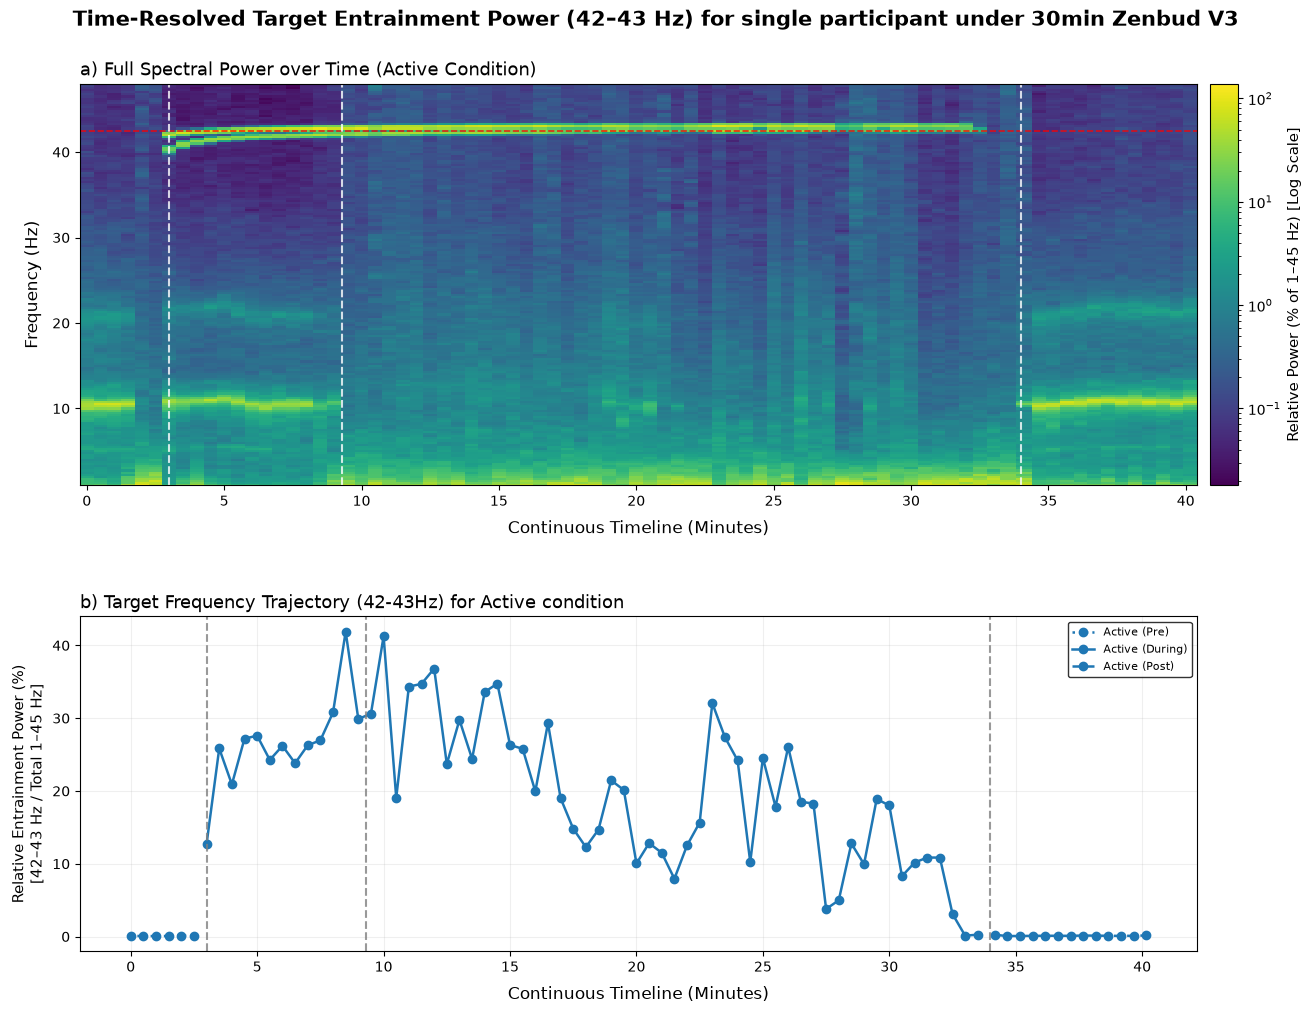

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LogNorm

# ==============================================================================
# STEP 4: ANALYZE & PLOT (SPECTROGRAM + LINE PLOT HYBRID)
# ==============================================================================

# 1. Average channels within each participant, time window, and frequency
participant_time_psd = (
    time_psd_df
    .groupby(
        [
            "participant", "eeg_visit", "condition", "phase",
            "time_window", "time_start", "time_end", "frequency"
        ],
        as_index=False
    )
    .agg(psd=("psd", "mean"))
)

group_cols = ["participant", "eeg_visit", "condition", "phase", "time_window", "time_start", "time_end"]

# 2. Compute Total Power (1-45 Hz) per window
total_power_df = (
    participant_time_psd
    .sort_values("frequency")
    .groupby(group_cols, as_index=False)
    .apply(
        lambda g: pd.Series({"total_power": np.trapezoid(g["psd"].values, g["frequency"].values)}),
        include_groups=False
    )
)

# Merge total power back into participant PSD data
participant_time_psd = pd.merge(participant_time_psd, total_power_df, on=group_cols)

# 3. Calculate Relative Power (%) for ALL frequencies (for the Spectrogram)
# Note: Bin width scaling (df) yields percent of spectral power
participant_time_psd["relative_power_pct"] = (
    participant_time_psd["psd"] / participant_time_psd["total_power"]
) * 100

# 4. Group Aggregation across participants
group_time_freq_cols = ["condition", "phase", "time_window", "time_start", "time_end", "frequency"]
group_spec_df = (
    participant_time_psd
    .groupby(group_time_freq_cols, as_index=False)
    .agg(mean_relative_power=("relative_power_pct", "mean"))
)

# 5. Extract Entrainment Power (42-43 Hz) specifically for the 1D Line Plot
entrainment_time_df = (
    participant_time_psd[
        (participant_time_psd["frequency"] >= 42) &
        (participant_time_psd["frequency"] <= 43)
    ]
    .groupby(group_cols, as_index=False)
    .agg(entrainment_power=("psd", lambda g: np.trapezoid(g, participant_time_psd.loc[g.index, "frequency"])))
)

# Calculate Relative Entrainment Power (%)
entrainment_time_df = pd.merge(entrainment_time_df, total_power_df, on=group_cols)
entrainment_time_df["relative_entrainment_pct"] = (
    (entrainment_time_df["entrainment_power"] / entrainment_time_df["total_power"]) * 100
)

group_time_cols = ["condition", "phase", "time_window", "time_start", "time_end"]
group_entrainment_time = (
    entrainment_time_df
    .groupby(group_time_cols, as_index=False)
    .agg(
        mean_relative_power=("relative_entrainment_pct", "mean"),
        sd_relative_power=("relative_entrainment_pct", "std"),
        n=("participant", "nunique")
    )
)

group_threshold = group_entrainment_time[group_entrainment_time["n"] >= 1].copy()

# ==============================================================================
# CALCULATE CONTINUOUS TIMELINE OFFSETS
# ==============================================================================
pre_duration_min = (
    group_threshold[group_threshold["phase"] == "pre"]["time_end"].max() / 60.0
    if "pre" in group_threshold["phase"].values else 0.0
)

during_duration_min = (
    group_threshold[group_threshold["phase"] == "during"]["time_end"].max() / 60.0
    if "during" in group_threshold["phase"].values else 0.0
)

post_duration_min = (
    group_threshold[group_threshold["phase"] == "post"]["time_end"].max() / 60.0
    if "post" in group_threshold["phase"].values else 0.0
)

start_stim_marker = pre_duration_min
end_stim_marker = start_stim_marker + during_duration_min
end_during_ec_marker = start_stim_marker + ((t_end_during_EC - t_start_stim) / 60.0)

# Add continuous x-position (in minutes) to group_spec_df
def get_continuous_time(row):
    time_min = row["time_start"] / 60.0
    if row["phase"] == "pre":
        return time_min
    elif row["phase"] == "during":
        return time_min + start_stim_marker
    elif row["phase"] == "post":
        return time_min + end_stim_marker + (10.0 / 60.0)
    return time_min

group_spec_df["time_min"] = group_spec_df.apply(get_continuous_time, axis=1)


# ==============================================================================
# FIGURE CREATION: STACKED 2D SPECTROGRAM + 1D LINE PLOT
# ==============================================================================
# Focus visualization on 'Active' condition for the spectrogram panel
active_spec_df = group_spec_df[group_spec_df["condition"] == "Active"]

# Pivot into 2D Matrix (Frequency x Time)
spec_pivot = active_spec_df.pivot(
    index="frequency",
    columns="time_min",
    values="mean_relative_power"
).sort_index(ascending=True)

# Use constrained_layout=True to properly space titles and colorbar
fig = plt.figure(figsize=(13, 9.5), facecolor="w", constrained_layout=True)

# ADD OVERALL FIGURE TITLE
fig.suptitle(
    "Time-Resolved Target Entrainment Power (42–43 Hz) for single participant under 30min Zenbud V3",
    fontsize=15,
    weight="bold",
    y=1.05
)

gs = gridspec.GridSpec(2, 2, figure=fig, height_ratios=[1.2, 1], width_ratios=[40, 1], hspace=0.12, wspace=0.02)

ax_spec = fig.add_subplot(gs[0, 0])
ax_line = fig.add_subplot(gs[1, 0])
cax = fig.add_subplot(gs[0, 1])

# --- PANEL A: 2D SPECTROGRAM ---
X, Y = np.meshgrid(spec_pivot.columns.values, spec_pivot.index.values)
safe_values = np.clip(spec_pivot.values, a_min=1e-4, a_max=None)

im = ax_spec.pcolormesh(
    X, Y, safe_values,
    shading="nearest",
    cmap="viridis",
    norm=LogNorm(vmin=np.nanmin(safe_values), vmax=np.nanmax(safe_values))
)

# COLORBAR WITH EXPLICIT UNITS
cbar = fig.colorbar(im, cax=cax)
cbar.set_label("Relative Power (% of 1–45 Hz) [Log Scale]", fontsize=11, color="black")

ax_spec.set_ylabel("Frequency (Hz)", fontsize=12, color="black", labelpad=8)
ax_spec.set_title("a) Full Spectral Power over Time (Active Condition)", fontsize=13, loc="left")
ax_spec.set_xlabel("Continuous Timeline (Minutes)", fontsize=12, color="black", labelpad=8)
ax_spec.set_ylim([FMIN, FMAX])
plt.setp(ax_spec.get_xticklabels(), visible=True, fontsize=10, color="black")
ax_spec.tick_params(axis='x', which='both', bottom=True, labelbottom=True)

# Target frequency highlight line on spectrogram
ax_spec.axhline(y=42.5, color="red", linestyle="--", linewidth=1.2, alpha=0.8, label="Entrainment Band (42–43 Hz)")

# --- PANEL B: 1D LINE PLOT ---
colors = {"Active": "#1f77b4", "Sham": "#ff7f0e"}
linestyles = {"pre": ":", "during": "-", "post": "--"}

for condition in ["Active", "Sham"]:
    for phase in ["pre", "during", "post"]:
        subset = group_threshold[
            (group_threshold["condition"] == condition) &
            (group_threshold["phase"] == phase)
        ].sort_values("time_start")

        if subset.empty:
            continue

        segment_time_mins = subset["time_start"] / 60.0

        if phase == "pre":
            time_in_mins = segment_time_mins
        elif phase == "during":
            time_in_mins = segment_time_mins + start_stim_marker
        elif phase == "post":
            time_in_mins = segment_time_mins + end_stim_marker + (10.0 / 60.0)

        y_vals = subset["mean_relative_power"]
        label = f"{condition} ({phase.capitalize()})"

        ax_line.plot(
            time_in_mins,
            y_vals,
            linestyle=linestyles[phase],
            color=colors[condition],
            marker="o",
            linewidth=1.8,
            label=label
        )

# ACCURATE AND DETAILED AXIS TITLES
ax_line.set_xlabel("Continuous Timeline (Minutes)", fontsize=12, color="black", labelpad=8)
ax_line.set_ylabel("Relative Entrainment Power (%)\n[42–43 Hz / Total 1–45 Hz]", fontsize=11, color="black")
ax_line.set_title("b) Target Frequency Trajectory (42-43Hz) for Active condition", fontsize=13, loc="left")
ax_line.grid(alpha=0.2)

# --- ADD SHARED VERTICAL TRANSITION MARKERS TO BOTH AXES ---
for ax in [ax_spec, ax_line]:
    if start_stim_marker > 0:
        ax.axvline(x=start_stim_marker, color="white" if ax == ax_spec else "gray", linestyle="--", alpha=0.8)
    ax.axvline(x=end_stim_marker, color="white" if ax == ax_spec else "gray", linestyle="--", alpha=0.8)
    ax.axvline(x=end_during_ec_marker, color="white" if ax == ax_spec else "gray", linestyle="--", alpha=0.8)

    for spine in ax.spines.values():
        spine.set_color("black")
        spine.set_visible(True)
    ax.set_facecolor("white")

# Add unified legend to line plot
ax_line.legend(loc="upper right", frameon=True, facecolor="white", edgecolor="black", fontsize=8)

plt.savefig(ANALYSIS_PATH / "Spectrogram_and_LinePlot_42-43Hz.png", dpi=300, bbox_inches="tight")
plt.show()